In [1]:
import zstandard as zstd

def decompress_zstd_file(input_file_path, output_file_path):
    # Create the decompressor context
    dctx = zstd.ZstdDecompressor()
    
    # Open the compressed file for reading in binary mode
    with open(input_file_path, 'rb') as compressed_file:
        # Open the target file for writing in binary mode
        with open(output_file_path, 'wb') as output_file:
            # Efficiently stream the decompression
            dctx.copy_stream(compressed_file, output_file)

# Usage example:
decompress_zstd_file('../data/raw/databento/ONDS/xnas-itch-20260325.mbo.ONDS.csv.zst', '../data/raw/databento/ONDS/20260325_ONDS.csv')

In [2]:
import pandas as pd

df = pd.read_parquet("../data/parquet/events/source=COINBASE/symbol=BTC-USDT/date=2026-03-23/part.parquet")

In [18]:
df[df["ts"]>=df["ts"].min()+300*10**9].index.min()

56782

In [22]:
df[df["ts"]>=1774224300023560000+5*10**9].index.min()

57717

In [23]:
df_1s = df.iloc[56782:57717]

In [24]:
df_1s["event_type"].value_counts()

event_type
ADD       468
CANCEL    467
Name: count, dtype: int64

In [34]:
import matplotlib.pyplot as plt
from datetime import datetime

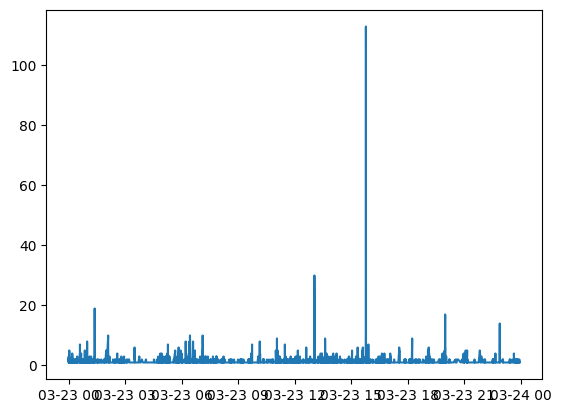

In [40]:
fill_time = df[df["event_type"]=="FILL"]["ts"].value_counts()
fill_time.sort_index(inplace=True)
ts = pd.to_datetime(fill_time.index, unit="ns")

plt.subplot()
plt.plot(ts, fill_time.to_numpy())

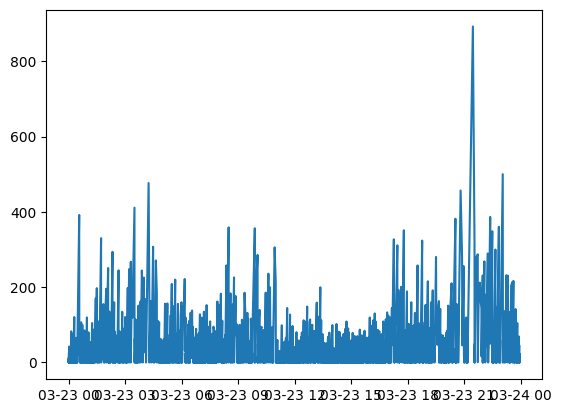

In [47]:
plt.subplot()
plt.plot(ts, ts.diff().total_seconds())

In [65]:
import numpy as np

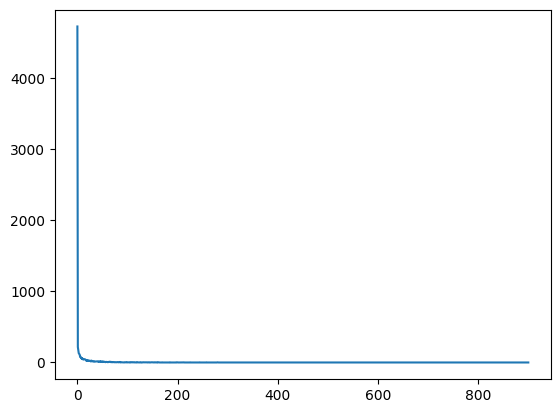

In [79]:
time_delta = ts.diff().total_seconds()
time_delta = time_delta.sort_values()
max_time_delta = time_delta.max()
ls = np.linspace(0, round(max_time_delta, -2),1000)
time_delta_distr = []
for i in range(1000):
    if i+1 == 1000:
        time_delta_distr.append(time_delta[time_delta>ls[i]].size)
    else:    
        time_delta_distr.append(time_delta[(time_delta<ls[i+1]) & (time_delta>ls[i])].size)
plt.subplot()
plt.plot(ls, time_delta_distr)

In [81]:
(time_delta[time_delta<600].size)/(time_delta.size)

0.9997267012845039

In [83]:
df[df["event_type"]=="FILL"]

,order_id,session_id,symbol,source,side,event_type,event_seq,ts,price,size,remaining_size,reason
1394,49cc96f2-a0fe-479d-b5e1-c3b985e904c0,1,BTC-USDT,COINBASE,BID,FILL,1,1774224004994567000,67896.77,0.001440,0.000000,FULL_FILL_TRADE
1395,274db138-9713-488d-bb33-b8c6d329bcc0,1,BTC-USDT,COINBASE,BID,FILL,1,1774224004994567000,67892.58,0.007040,0.000000,FULL_FILL_TRADE
3008,aca6308d-8b82-4a12-b141-2d25ca6009b9,1,BTC-USDT,COINBASE,ASK,FILL,1,1774224011228400000,67896.72,0.002943,0.000000,FULL_FILL_TRADE
3009,da869860-8a06-4222-abe9-7c6aa863ea4d,1,BTC-USDT,COINBASE,ASK,FILL,1,1774224011228400000,67903.37,0.004229,0.000000,FULL_FILL_TRADE
3010,55011c7e-dc7e-4770-bb08-d7bf0c54f3ec,1,BTC-USDT,COINBASE,ASK,FILL,1,1774224011230561000,67915.03,0.003407,0.005293,PARTIAL_FILL_TRADE
...,...,...,...,...,...,...,...,...,...,...,...,...
12090793,fc694e0c-4742-4fc8-bbb0-3fe629e26f7a,1,BTC-USDT,COINBASE,ASK,FILL,1,1774310218470165000,70924.67,0.001714,0.077708,PARTIAL_FILL_TRADE
12090794,fc694e0c-4742-4fc8-bbb0-3fe629e26f7a,1,BTC-USDT,COINBASE,ASK,FILL,2,1774310218470812000,70924.67,0.002795,0.074914,PARTIAL_FILL_TRADE
12090800,fc694e0c-4742-4fc8-bbb0-3fe629e26f7a,1,BTC-USDT,COINBASE,ASK,FILL,3,1774310218475326000,70924.67,0.004195,0.070719,PARTIAL_FILL_TRADE
12090801,fc694e0c-4742-4fc8-bbb0-3fe629e26f7a,1,BTC-USDT,COINBASE,ASK,FILL,4,1774310218475532000,70924.67,0.003045,0.067674,PARTIAL_FILL_TRADE
